In [1]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import  LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df['color'].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [4]:
df['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [5]:
le = LabelEncoder()
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])
df['cut'] = le.fit_transform(df['cut'])

In [6]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [7]:
x = df.drop('price' ,  axis = 1)
y = df['price']

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [10]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=x_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

C:\Users\admin\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Epoch 1/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8995038.0000 - mae: 1624.1193 - val_loss: 1469255.7500 - val_mae: 727.2275
Epoch 2/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1654636.8750 - mae: 696.5802 - val_loss: 1292732.2500 - val_mae: 671.3225
Epoch 3/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1547856.7500 - mae: 662.6750 - val_loss: 1229373.7500 - val_mae: 644.8196
Epoch 4/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1457666.5000 - mae: 642.4856 - val_loss: 1172149.6250 - val_mae: 622.7192
Epoch 5/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1367220.7500 - mae: 612.7704 - val_loss: 1102851.0000 - val_mae: 590.2330
Epoch 6/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1266798.6250 - mae: 578.6212 - val_loss: 1021386.1875 - val_mae: 553.8698
Epoch 7/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1156486.7500 - mae: 543.1281 - val_loss: 926224.1250 - val_mae: 519.5870
Epoch 8/100
1079/1079 ━━━━━━━━━━━━━━━━━━━

In [13]:
loss,accuracy = model.evaluate(x_train,y_train)
print('Test Accuracy = ' , accuracy)

1349/1349 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6845.5527 - mae: 56.8663
Test Accuracy =  56.8663330078125


In [14]:
loss, mae = model.evaluate(x_test, y_test)

print("Loss :", loss)
print("MAE  :", mae)

338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6819.8330 - mae: 57.0566
Loss : 6819.8330078125
MAE  : 57.056583404541016


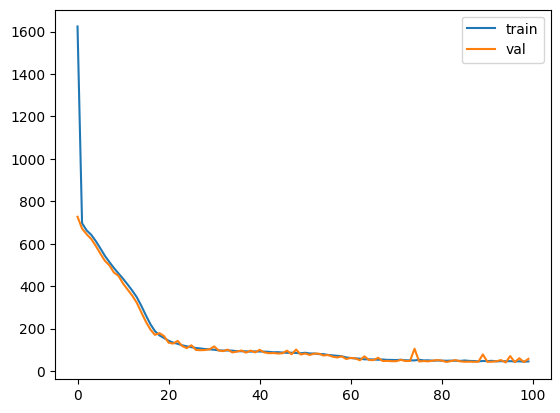

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['mae'],label='train')
plt.plot(history.history['val_mae'],label='val')
plt.legend()
plt.show()

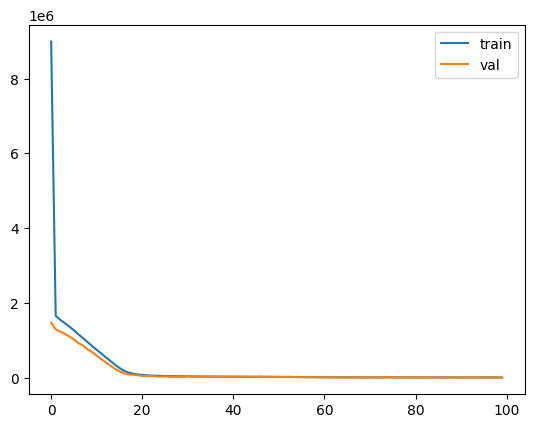

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.legend()
plt.show()

In [17]:
pred = model.predict(x_test)
print(pred)

338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[ 497.65924]
 [2169.6458 ]
 [1155.1998 ]
 ...
 [ 646.19116]
 [9878.097  ]
 [3680.8616 ]]


In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

MAE  : 57.056583404541016
RMSE : 82.58228022894802
R2   : 0.9995709657669067


In [25]:
new_data = pd.DataFrame({
    'unnamed':[0],
    'carat':[0.50],
    'cut':['Ideal'],
    'color':['E'],
    'clarity':['VS1'],
    'depth':[61.5],
    'table':[55.0],
    'x':[5.10],
    'y':[5.12],
    'z':[3.15]
})

In [29]:
from sklearn.preprocessing import LabelEncoder

le_cut = LabelEncoder()
le_color = LabelEncoder()
le_clarity = LabelEncoder()

new_data['cut'] = le_cut.fit_transform(new_data['cut'])
new_data['color'] = le_color.fit_transform(new_data['color'])
new_data['clarity'] = le_clarity.fit_transform(new_data['clarity'])

In [21]:
print(x_train.shape)

(43152, 10)


In [24]:
print(x)

       Unnamed: 0  carat  cut  color  clarity  depth  table     x     y     z
0               1   0.23    2      1        3   61.5   55.0  3.95  3.98  2.43
1               2   0.21    3      1        2   59.8   61.0  3.89  3.84  2.31
2               3   0.23    1      1        4   56.9   65.0  4.05  4.07  2.31
3               4   0.29    3      5        5   62.4   58.0  4.20  4.23  2.63
4               5   0.31    1      6        3   63.3   58.0  4.34  4.35  2.75
...           ...    ...  ...    ...      ...    ...    ...   ...   ...   ...
53935       53936   0.72    2      0        2   60.8   57.0  5.75  5.76  3.50
53936       53937   0.72    1      0        2   63.1   55.0  5.69  5.75  3.61
53937       53938   0.70    4      0        2   62.8   60.0  5.66  5.68  3.56
53938       53939   0.86    3      4        3   61.0   58.0  6.15  6.12  3.74
53939       53940   0.75    2      0        3   62.2   55.0  5.83  5.87  3.64

[53940 rows x 10 columns]


In [30]:
print(new_data.dtypes)

unnamed      int64
carat      float64
cut          int64
color        int64
clarity      int64
depth      float64
table      float64
x          float64
y          float64
z          float64
dtype: object


In [31]:
print(new_data)

   unnamed  carat  cut  color  clarity  depth  table    x     y     z
0        0    0.5    0      0        0   61.5   55.0  5.1  5.12  3.15


In [ ]:
prediction = model.predict(new_data)
print("Predicted Price:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Price: 35106.293


In [ ]:
accuracy = r2 * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 99.96%
